# 🗞️ LDA Topic Modeling — Bayesian Hyperparameter Optimization
## 20 Newsgroups Dataset

### ⚡ Speed Strategy
Each LDA evaluation was taking 340–413s on the full corpus. The fix:

| Bottleneck | Cause | Fix |
|---|---|---|
| Slow LDA fit | `max_iter=20` on 18k docs | Use **4k-doc subsample** during search |
| Slow coherence | C_v computed on all tokens | Coherence on same subsample |
| Low parallelism | Colab has 2 CPUs | Keep `n_jobs=-1` but reduce data |
| Too many iterations | 20 per search call | Drop to **7** for search, **40** for final |

**Result:** ~15s per evaluation → 30 calls ≈ **8 minutes** total

The subsample is **stratified** (equal docs per category) so the search signal is representative, and the final model trains on the full corpus.

## ⚙️ Cell 1 — Install Dependencies

In [1]:
!pip install kagglehub gensim pyLDAvis wordcloud scikit-optimize --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.2 MB/s eta 0:00:00


## 📦 Cell 2 — Imports

In [2]:
import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from wordcloud import WordCloud
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

import gensim.corpora as corpora
from gensim.models import CoherenceModel

from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
print('✅ Imports done')

✅ Imports done


## 🔧 Cell 3 — Configuration

In [3]:
# ── Search settings (fast) ────────────────────────────────────
SEARCH_N_DOCS   = 4000    # stratified subsample used during search
SEARCH_MAX_ITER = 7       # LDA iterations per search call  (~15s/call)
N_CALLS         = 30      # total Bayesian evaluations
N_INITIAL_PTS   = 8       # random points before GP kicks in

# ── Final model settings (thorough) ──────────────────────────
FINAL_MAX_ITER  = 40      # retrain on full corpus with best params

# ── Vectorizer ───────────────────────────────────────────────
MAX_FEATURES    = 5000
MAX_DF          = 0.90
MIN_DF          = 5
N_TOP_WORDS     = 15
RANDOM_STATE    = 42

print(f'Search: {N_CALLS} evals on {SEARCH_N_DOCS}-doc subsample, max_iter={SEARCH_MAX_ITER}')
print(f'Final : full corpus, max_iter={FINAL_MAX_ITER}')
print(f'Estimated search time: ~{N_CALLS * 15 / 60:.0f} min')

Search: 30 evals on 4000-doc subsample, max_iter=7
Final : full corpus, max_iter=40
Estimated search time: ~8 min


## 📥 Cell 4 — Load Dataset

In [4]:
from sklearn.datasets import fetch_20newsgroups

print("Downloading 20 Newsgroups dataset via scikit-learn...")
# Fetch both train and test to get the full ~18k corpus
newsgroups_all = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

categories = list(newsgroups_all.target_names)
cat2idx = {c: i for i, c in enumerate(categories)}

# Construct the DataFrame
records = []
for text, label_idx in zip(newsgroups_all.data, newsgroups_all.target):
    records.append({
        'text': text,
        'category': categories[label_idx],
        'label': label_idx
    })

df_raw = pd.DataFrame(records)
print(f'Loaded {len(df_raw):,} docs across {len(categories)} categories')

Loaded 18,846 docs across 20 categories


## 🧹 Cell 5 — Clean Text

In [13]:
NEWSGROUP_STOPS = [
    'edu','com','gov','org','net','writes','article','subject','lines',
    'nntp','posting','host','university','email','mail','said','say',
    'know','think','like','just','does','did','people','time','good',
    'make','way','use','used','using'
]

def clean_text(text):
    # strip email headers and quoted lines
    lines = [l for l in text.split('\n')
             if not re.match(r'^(From|Subject|Organization|Lines|NNTP|Path|X-|Message|Date|Reply):', l)
             and not l.startswith('>')]
    text = ' '.join(lines).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\b\w{1,2}\b', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

if 'text' not in df_raw.columns or len(df_raw) == 0:
    raise ValueError(
        "df_raw is empty or missing the 'text' column! "
        "Please check Cell 4 (Load Dataset) to ensure the dataset downloaded and extracted correctly."
    )
else:
    df_raw['clean'] = df_raw['text'].apply(clean_text)
    df_raw = df_raw[df_raw['clean'].str.split().str.len() >= 10].reset_index(drop=True)
    print(f'After filtering: {len(df_raw):,} docs remain')

After filtering: 17,543 docs remain


## ✂️ Cell 6 — Build Full & Search Subsets
The **subsample** is used only during Bayesian search to keep each evaluation fast (~15s).
The **full corpus** is used to train the final model once best params are found.

In [6]:
COMBINED_STOPS = list(ENGLISH_STOP_WORDS) + NEWSGROUP_STOPS

# ── Stratified subsample: equal docs per category ────────────
docs_per_cat = SEARCH_N_DOCS // len(categories)
df_sub = (
    df_raw.groupby('category', group_keys=False)
    .apply(lambda g: g.sample(min(len(g), docs_per_cat), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)
print(f'Subsample: {len(df_sub):,} docs ({docs_per_cat}/category)')

# ── Vectorize subsample (used during search) ──────────────────
vec_sub = CountVectorizer(
    max_df=MAX_DF, min_df=2, max_features=MAX_FEATURES,
    stop_words=COMBINED_STOPS
)
dtm_sub  = vec_sub.fit_transform(df_sub['clean'])
feat_sub = vec_sub.get_feature_names_out()
tok_sub  = [doc.split() for doc in df_sub['clean']]
dict_sub = corpora.Dictionary(tok_sub)
print(f'Subsample DTM: {dtm_sub.shape}  vocab={len(feat_sub):,}')

# ── Vectorize full corpus (used for final model) ──────────────
vec_full = CountVectorizer(
    max_df=MAX_DF, min_df=MIN_DF, max_features=MAX_FEATURES,
    stop_words=COMBINED_STOPS
)
dtm_full  = vec_full.fit_transform(df_raw['clean'])
feat_full = vec_full.get_feature_names_out()
tok_full  = [doc.split() for doc in df_raw['clean']]
dict_full = corpora.Dictionary(tok_full)
print(f'Full DTM     : {dtm_full.shape}  vocab={len(feat_full):,}')

Subsample: 4,000 docs (200/category)
Subsample DTM: (4000, 5000)  vocab=5,000
Full DTM     : (17543, 5000)  vocab=5,000


## 📊 Cell 7 — Baseline (n=20, default params, full corpus)

In [7]:
def coherence_cv(model, feat_names, tokenized, dictionary):
    topics_words = [[feat_names[i] for i in t.argsort()[:-N_TOP_WORDS-1:-1]]
                    for t in model.components_]
    cm = CoherenceModel(topics=topics_words, texts=tokenized,
                        dictionary=dictionary, coherence='c_v')
    return cm.get_coherence()

print('Training baseline (n=20, defaults, full corpus)...')
t0 = time.time()
lda_base = LatentDirichletAllocation(
    n_components=20, max_iter=FINAL_MAX_ITER,
    learning_method='online', learning_offset=50.0,
    random_state=RANDOM_STATE, n_jobs=-1
)
lda_base.fit(dtm_full)
baseline_ll  = lda_base.score(dtm_full)
baseline_pp  = lda_base.perplexity(dtm_full)
baseline_coh = coherence_cv(lda_base, feat_full, tok_full, dict_full)
print(f'Done in {time.time()-t0:.0f}s')
print(f'  Log-Likelihood : {baseline_ll:,.2f}')
print(f'  Perplexity     : {baseline_pp:,.2f}')
print(f'  Coherence (Cv) : {baseline_coh:.4f}')

Training baseline (n=20, defaults, full corpus)...
Done in 352s
  Log-Likelihood : -8,413,293.49
  Perplexity     : 1,819.32
  Coherence (Cv) : 0.6332


## 🔬 Cell 8 — Bayesian Search (on subsample)

```
 Calls 1–8   : Random exploration (build initial GP)
 Calls 9–30  : GP surrogate → Expected Improvement acquisition
               picks next config, balancing exploration vs exploitation

 Each call   : fit LDA on 4k-doc subsample, max_iter=7  → ~15s
 Total       : ~8 min
```

In [8]:
search_space = [
    Integer(10, 35,   name='n_components',     prior='uniform'),
    Real(0.01,  1.0,  name='doc_topic_prior',  prior='log-uniform'),
    Real(0.001, 0.5,  name='topic_word_prior', prior='log-uniform'),
    Real(0.50,  0.90, name='learning_decay',   prior='uniform'),
]

search_history = []
call_counter   = [0]

@use_named_args(search_space)
def objective(n_components, doc_topic_prior, topic_word_prior, learning_decay):
    call_counter[0] += 1
    t0 = time.time()

    model = LatentDirichletAllocation(
        n_components=int(n_components),
        doc_topic_prior=doc_topic_prior,
        topic_word_prior=topic_word_prior,
        learning_decay=learning_decay,
        learning_method='online',
        learning_offset=50.0,
        max_iter=SEARCH_MAX_ITER,     # ← fast: 7 iters on subsample
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(dtm_sub)               # ← fast: 4k docs

    # coherence on subsample (fast, still representative)
    coh  = coherence_cv(model, feat_sub, tok_sub, dict_sub)
    pp   = model.perplexity(dtm_sub)
    secs = time.time() - t0

    search_history.append({
        'call': call_counter[0],
        'n_components': int(n_components),
        'doc_topic_prior': round(doc_topic_prior, 5),
        'topic_word_prior': round(topic_word_prior, 5),
        'learning_decay': round(learning_decay, 4),
        'coherence': round(coh, 5),
        'perplexity': round(pp, 2),
        'time_s': round(secs, 1)
    })

    phase = 'RANDOM' if call_counter[0] <= N_INITIAL_PTS else 'BAYES '
    print(f'  [{phase} {call_counter[0]:02d}/{N_CALLS}] '
          f'n={int(n_components):2d} | α={doc_topic_prior:.4f} | β={topic_word_prior:.4f} | '
          f'decay={learning_decay:.3f} → coh={coh:.4f}  pp={pp:,.0f}  ({secs:.0f}s)')

    return -coh

print(f'Starting Bayesian search: {N_CALLS} evals on {len(df_sub):,}-doc subsample\n')
t_total = time.time()

result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=N_CALLS,
    n_initial_points=N_INITIAL_PTS,
    acq_func='EI',
    xi=0.01,
    noise=0.01,
    random_state=RANDOM_STATE,
    verbose=False
)

best_params = {
    'n_components':     int(result.x[0]),
    'doc_topic_prior':  result.x[1],
    'topic_word_prior': result.x[2],
    'learning_decay':   result.x[3],
}
best_coh_search = -result.fun

print(f'\n✅  Search done in {(time.time()-t_total)/60:.1f} min')
print(f'Best coherence (on subsample): {best_coh_search:.4f}')
print(f'Best params: {best_params}')

Starting Bayesian search: 30 evals on 4,000-doc subsample

  [RANDOM 01/30] n=30 | α=0.0233 | β=0.1272 | decay=0.739 → coh=0.5108  pp=2,322  (22s)
  [RANDOM 02/30] n=21 | α=0.0158 | β=0.0174 | decay=0.633 → coh=0.5112  pp=2,561  (23s)
  [RANDOM 03/30] n=14 | α=0.2003 | β=0.0014 | decay=0.789 → coh=0.5217  pp=4,103  (22s)
  [RANDOM 04/30] n=33 | α=0.0100 | β=0.4764 | decay=0.747 → coh=0.4778  pp=2,309  (25s)
  [RANDOM 05/30] n=25 | α=0.0103 | β=0.0012 | decay=0.710 → coh=0.5171  pp=3,112  (22s)
  [RANDOM 06/30] n=20 | α=0.0124 | β=0.4248 | decay=0.593 → coh=0.5016  pp=2,241  (21s)
  [RANDOM 07/30] n=12 | α=0.1725 | β=0.0108 | decay=0.893 → coh=0.5100  pp=3,315  (19s)
  [RANDOM 08/30] n=22 | α=0.5247 | β=0.0686 | decay=0.680 → coh=0.5004  pp=2,585  (22s)
  [BAYES  09/30] n=22 | α=0.2208 | β=0.0010 | decay=0.635 → coh=0.4901  pp=2,869  (24s)
  [BAYES  10/30] n=14 | α=0.1998 | β=0.0014 | decay=0.788 → coh=0.5181  pp=4,089  (21s)
  [BAYES  11/30] n=14 | α=0.2036 | β=0.0014 | decay=0.791 → c

## 📋 Cell 9 — Search Results Table

In [9]:
df_search = pd.DataFrame(search_history).sort_values('coherence', ascending=False).reset_index(drop=True)
print('Top 10 configs by coherence (on subsample):')
print(df_search[['call','n_components','doc_topic_prior','topic_word_prior',
                  'learning_decay','coherence','perplexity','time_s']].head(10).to_string(index=False))
df_search.to_csv('bayesian_search_results.csv', index=False)
print('\n💾 Saved → bayesian_search_results.csv')

Top 10 configs by coherence (on subsample):
 call  n_components  doc_topic_prior  topic_word_prior  learning_decay  coherence  perplexity  time_s
   25            17          0.01617           0.01962          0.7585    0.53726     2418.81    20.7
   20            28          0.01347           0.10739          0.6190    0.52919     2382.82    21.8
   28            18          0.01000           0.13890          0.7043    0.52416     2322.46    19.3
   11            14          0.20365           0.00136          0.7909    0.52331     4188.49    20.4
    3            14          0.20034           0.00142          0.7888    0.52171     4103.24    21.5
   23            28          0.01000           0.22440          0.6407    0.52144     2367.46    21.4
   30            22          0.16679           0.02253          0.7096    0.51943     2465.84    21.8
   10            14          0.19975           0.00143          0.7884    0.51807     4088.84    21.2
    5            25          0.01033  

## 🏆 Cell 10 — Train Final Model on Full Corpus
Best params from search, now trained on all ~18k docs with more iterations.

In [10]:
print(f'Retraining on full corpus with best params (max_iter={FINAL_MAX_ITER})...')
print(f'  {best_params}\n')
t0 = time.time()

lda = LatentDirichletAllocation(
    n_components=best_params['n_components'],
    doc_topic_prior=best_params['doc_topic_prior'],
    topic_word_prior=best_params['topic_word_prior'],
    learning_decay=best_params['learning_decay'],
    learning_method='online',
    learning_offset=50.0,
    max_iter=FINAL_MAX_ITER,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)
lda.fit(dtm_full)

N_TOPICS        = best_params['n_components']
log_likelihood  = lda.score(dtm_full)
perplexity      = lda.perplexity(dtm_full)
coherence_score = coherence_cv(lda, feat_full, tok_full, dict_full)

doc_topic_matrix            = lda.transform(dtm_full)
df_raw['dominant_topic']    = doc_topic_matrix.argmax(axis=1) + 1
df_raw['topic_confidence']  = doc_topic_matrix.max(axis=1)

print(f'\nDone in {time.time()-t0:.0f}s')
print('='*55)
print('FINAL MODEL vs BASELINE')
print('='*55)
print(f'  n_topics        : {N_TOPICS}  (was 20)')
print(f'  Log-Likelihood  : {log_likelihood:>14,.2f}   (was {baseline_ll:,.2f})')
print(f'  Perplexity      : {perplexity:>14,.2f}   (was {baseline_pp:,.2f})')
print(f'  Coherence (Cv)  : {coherence_score:>14.4f}   (was {baseline_coh:.4f})  '
      f'Δ={coherence_score-baseline_coh:+.4f} ({(coherence_score/baseline_coh-1)*100:+.1f}%)')
print('='*55)

Retraining on full corpus with best params (max_iter=40)...
  {'n_components': 17, 'doc_topic_prior': 0.016165118094561653, 'topic_word_prior': 0.019615775570337883, 'learning_decay': 0.7585357617509249}

iteration: 1 of max_iter: 40
iteration: 2 of max_iter: 40
iteration: 3 of max_iter: 40
iteration: 4 of max_iter: 40
iteration: 5 of max_iter: 40
iteration: 6 of max_iter: 40
iteration: 7 of max_iter: 40
iteration: 8 of max_iter: 40
iteration: 9 of max_iter: 40
iteration: 10 of max_iter: 40
iteration: 11 of max_iter: 40
iteration: 12 of max_iter: 40
iteration: 13 of max_iter: 40
iteration: 14 of max_iter: 40
iteration: 15 of max_iter: 40
iteration: 16 of max_iter: 40
iteration: 17 of max_iter: 40
iteration: 18 of max_iter: 40
iteration: 19 of max_iter: 40
iteration: 20 of max_iter: 40
iteration: 21 of max_iter: 40
iteration: 22 of max_iter: 40
iteration: 23 of max_iter: 40
iteration: 24 of max_iter: 40
iteration: 25 of max_iter: 40
iteration: 26 of max_iter: 40
iteration: 27 of max_ite

## 📋 Cell 11 — Top Words Per Topic

In [11]:
def get_top_words_dict(model, feat_names, n=N_TOP_WORDS):
    return {f'Topic {i+1}': [feat_names[j] for j in t.argsort()[:-n-1:-1]]
            for i, t in enumerate(model.components_)}

topics_dict = get_top_words_dict(lda, feat_full)
print('='*70)
for name, words in topics_dict.items():
    print(f'{name:10s}: {" | ".join(words)}')
print('='*70)

Topic 1   : don | point | really | want | question | right | believe | doesn | things | better | fact | sure | thing | different | read
Topic 2   : space | nasa | research | earth | center | launch | science | program | data | shuttle | new | national | orbit | mission | energy
Topic 3   : president | states | government | stephanopoulos | clinton | congress | united | american | myers | going | new | state | house | administration | right
Topic 4   : file | program | ftp | files | available | windows | window | image | version | server | graphics | pub | code | display | software
Topic 5   : list | send | new | thanks | information | interested | price | address | sale | sell | offer | post | info | looking | book
Topic 6   : god | jesus | bible | church | christian | christ | christians | believe | faith | religion | man | lord | life | word | sin
Topic 7   : gun | law | fbi | police | guns | rights | children | government | crime | koresh | laws | control | weapons | batf | court
To

---
# 📈 Cell 12 — All Visualizations

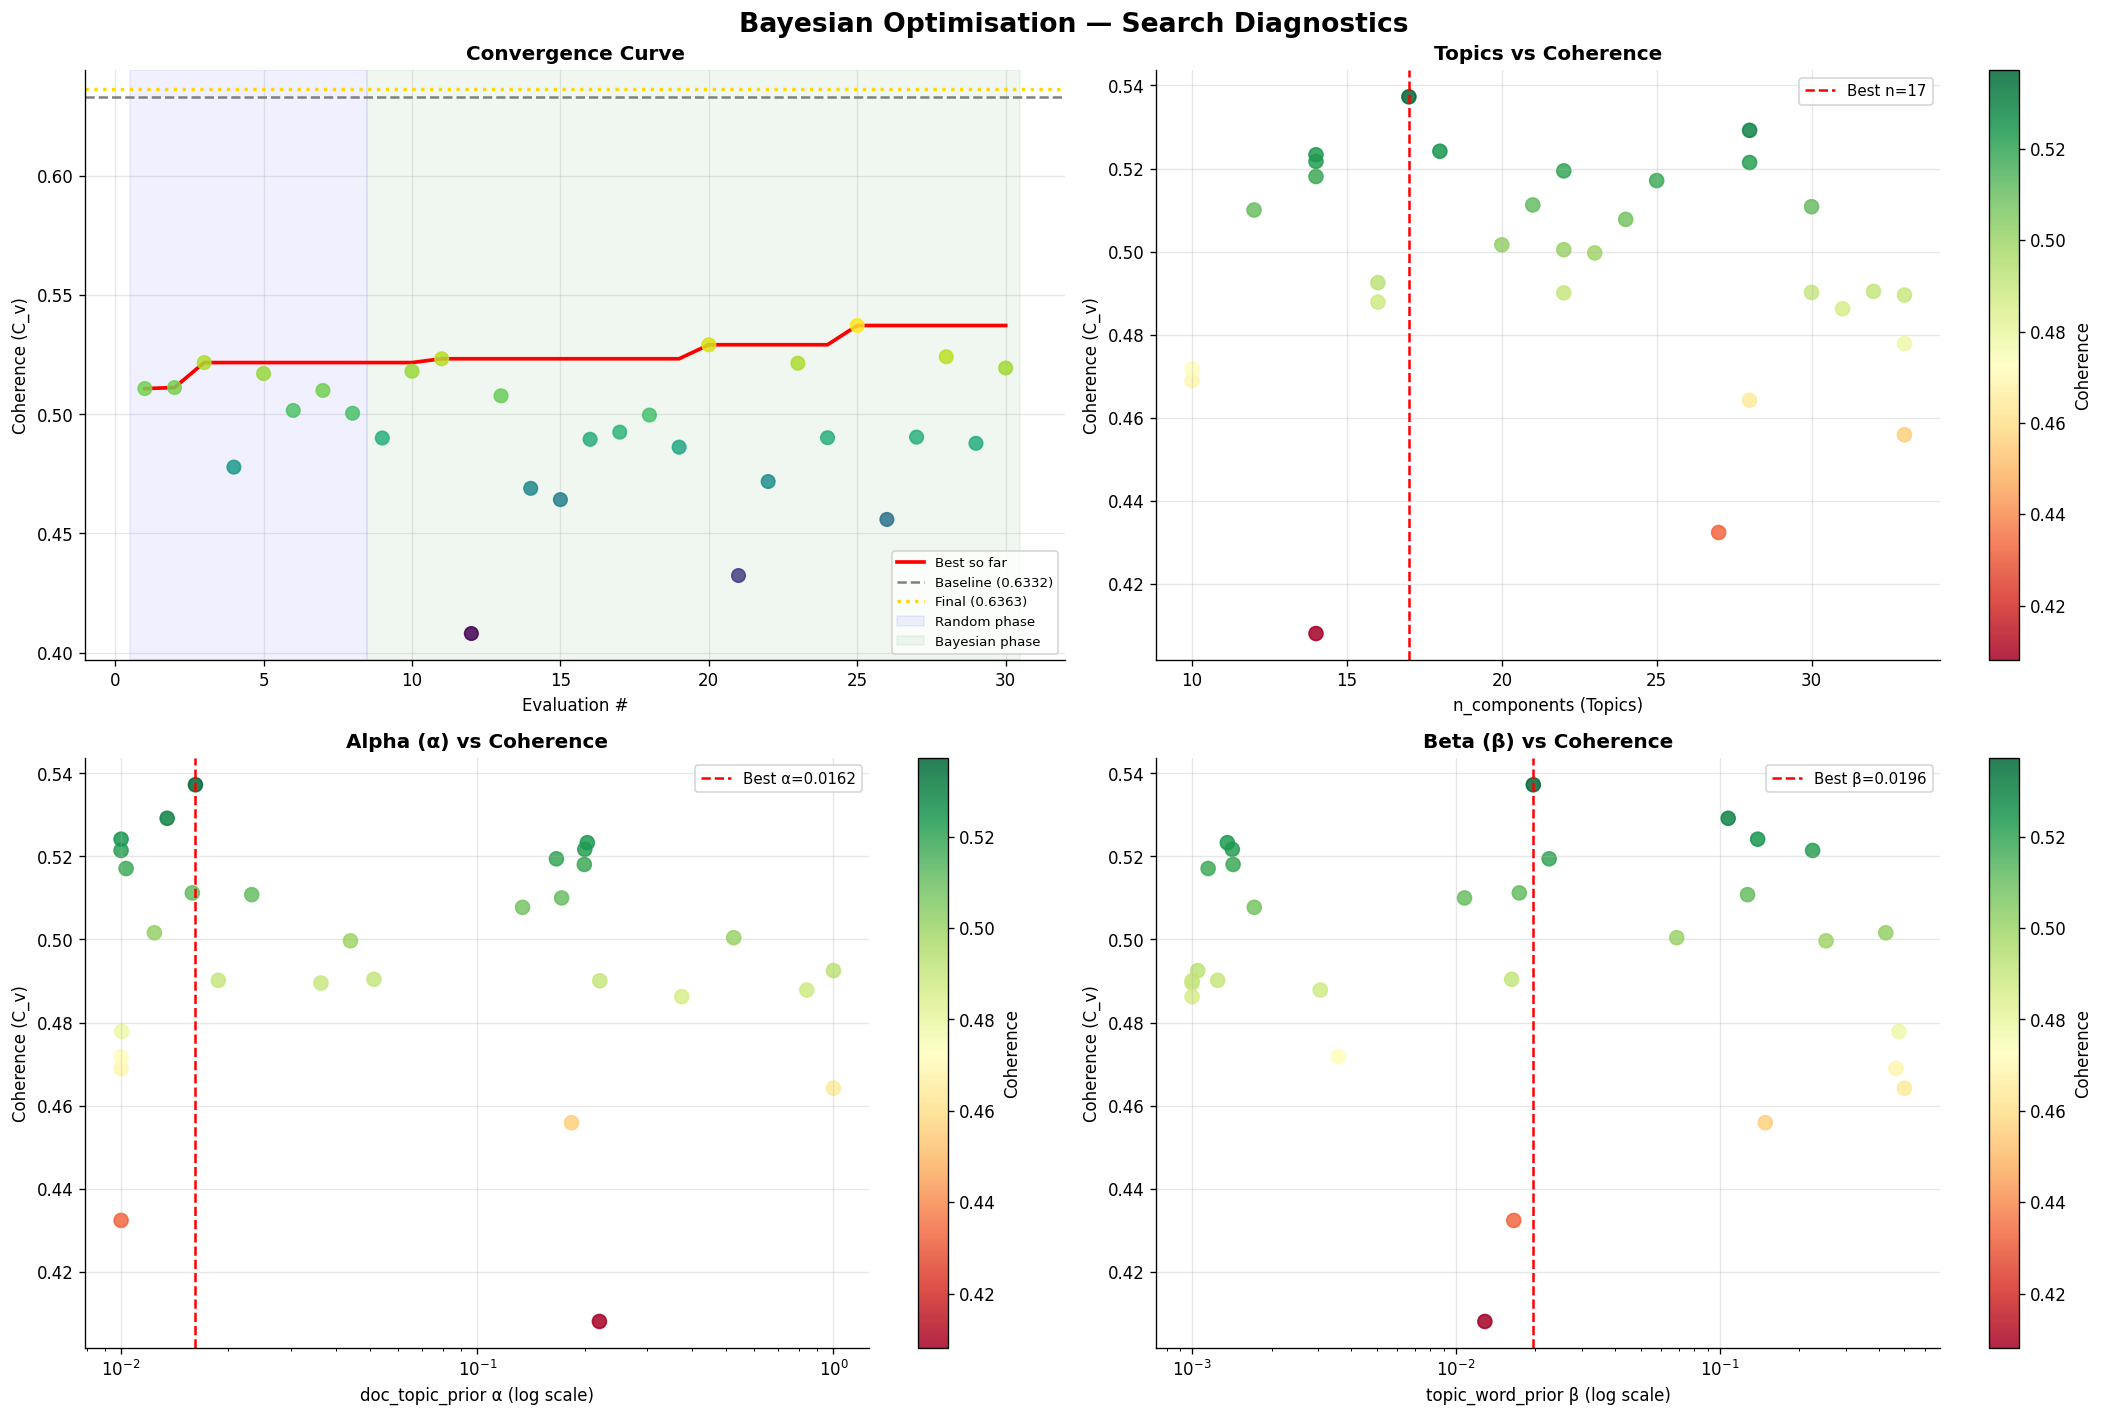

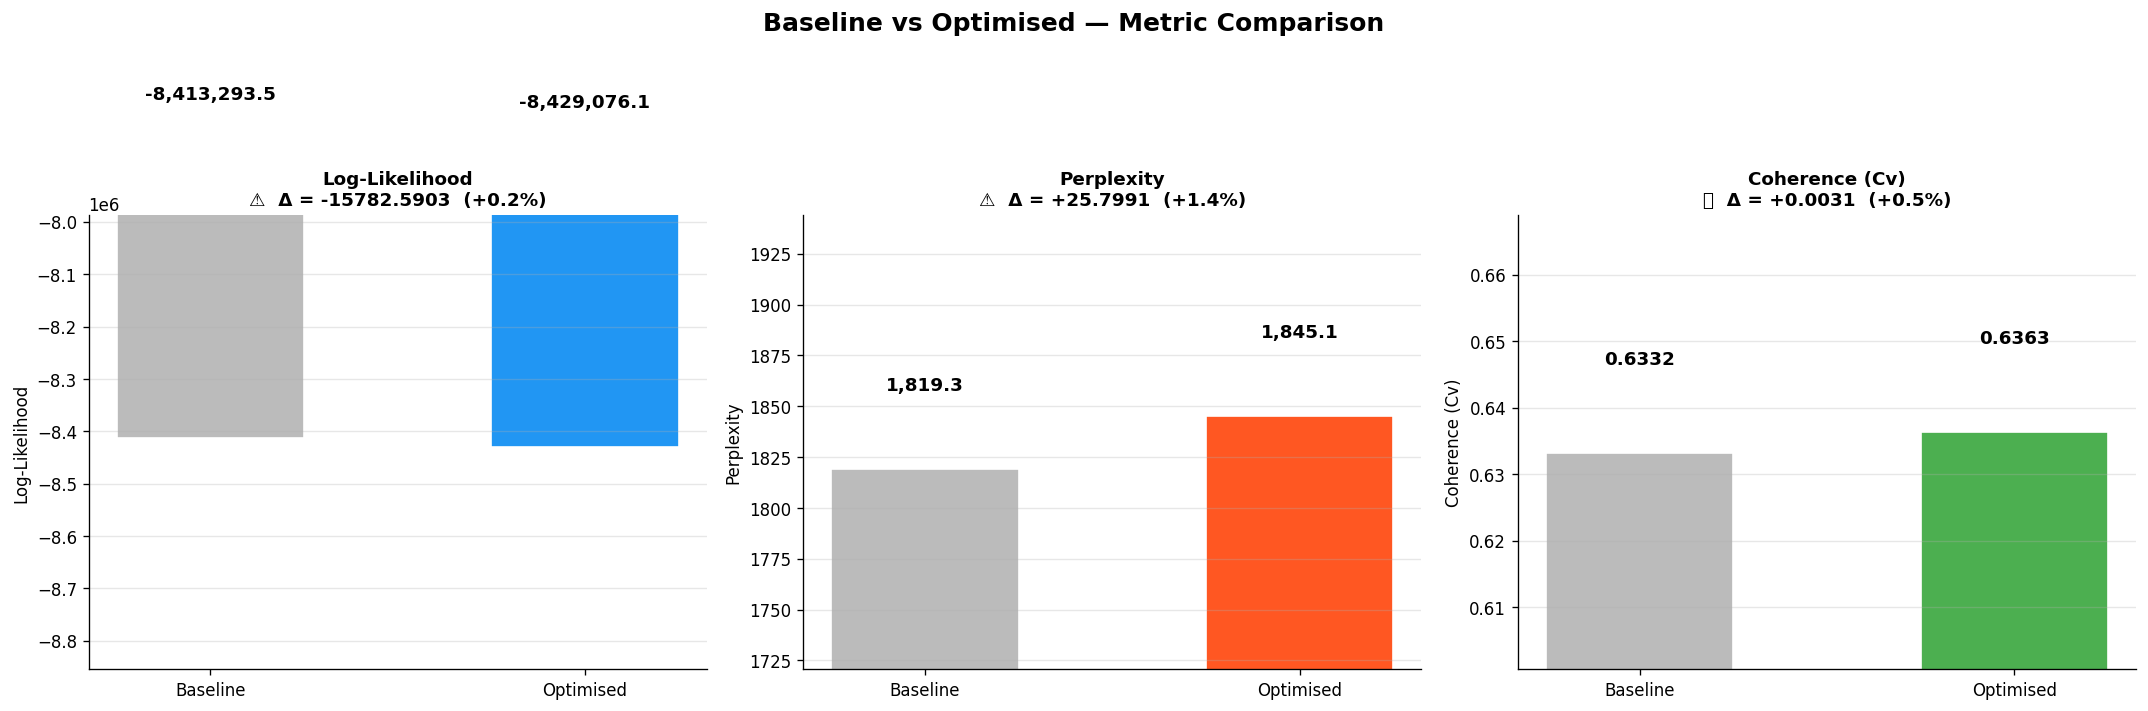

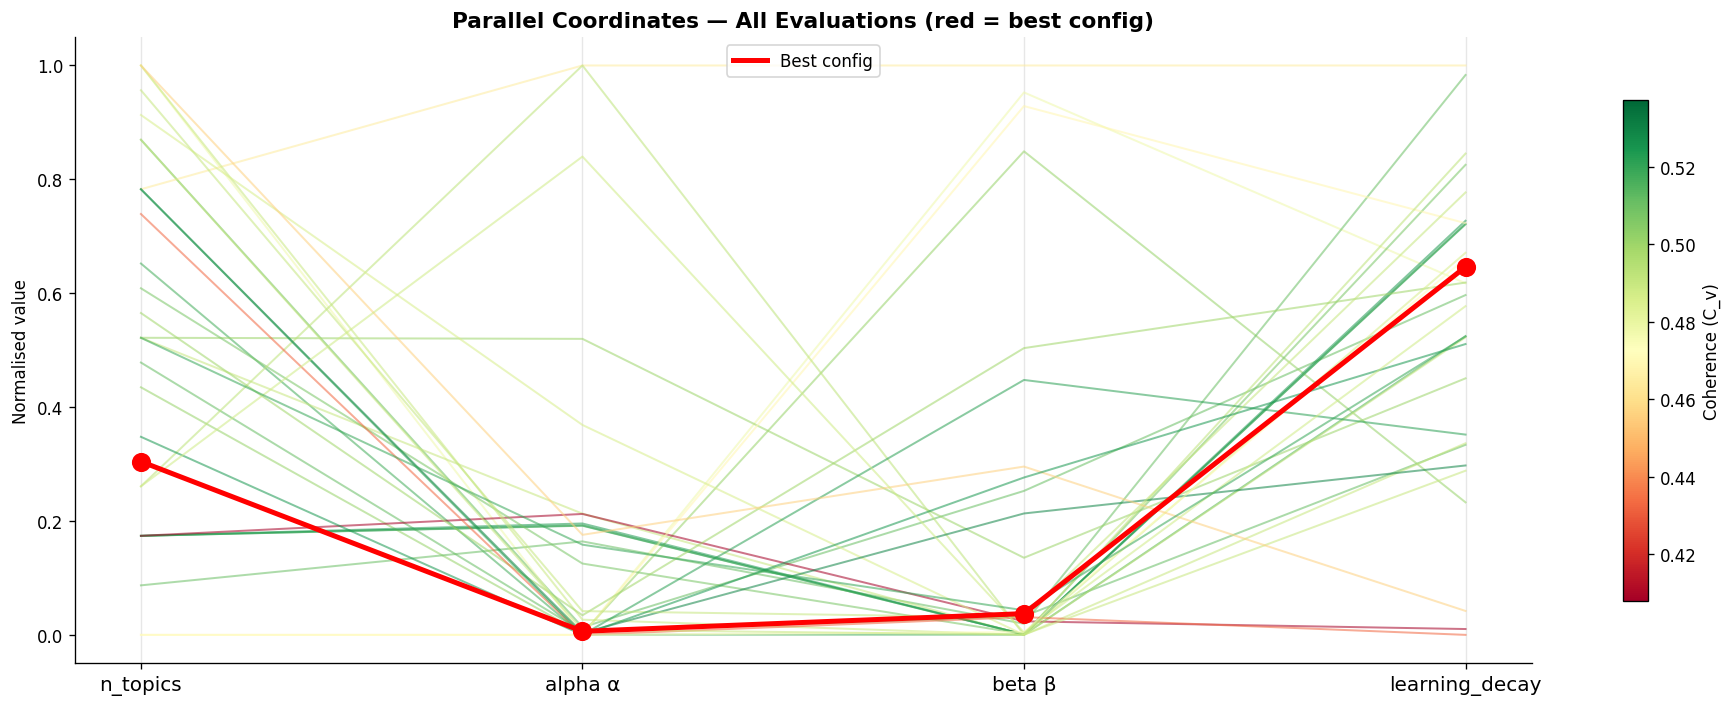

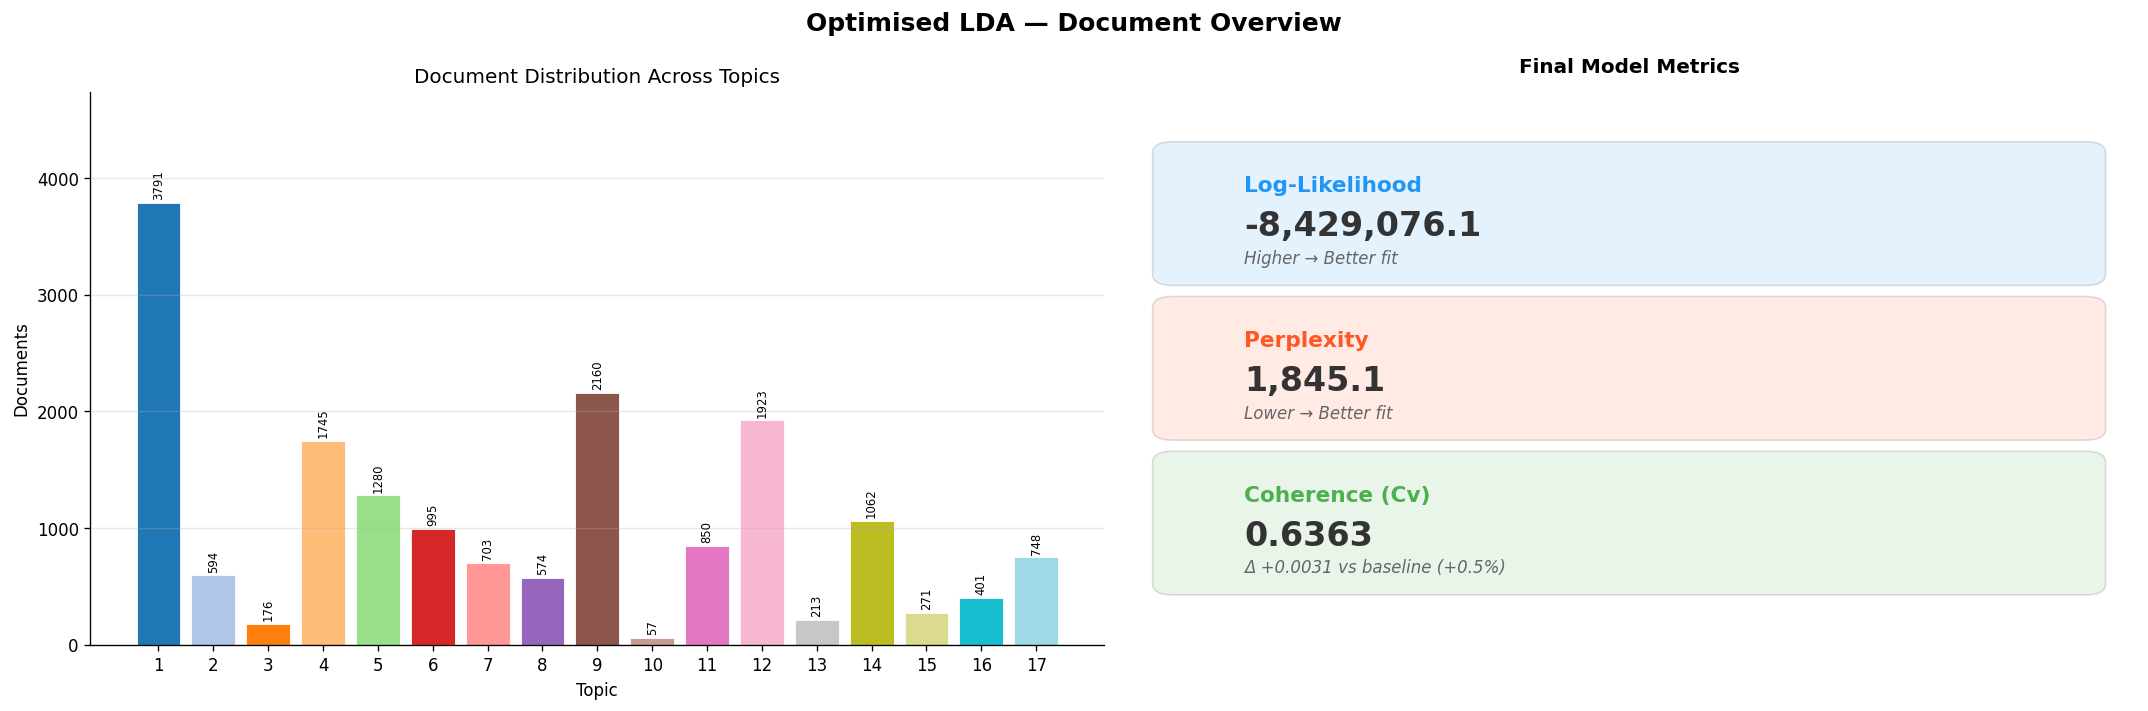

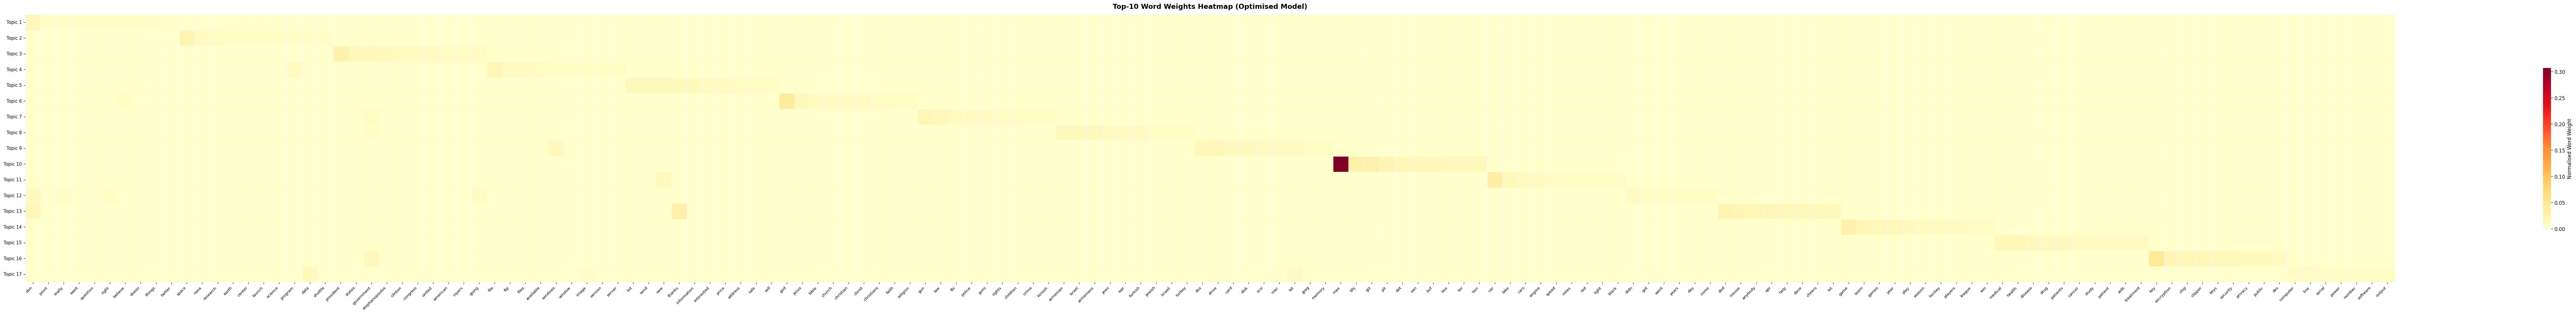

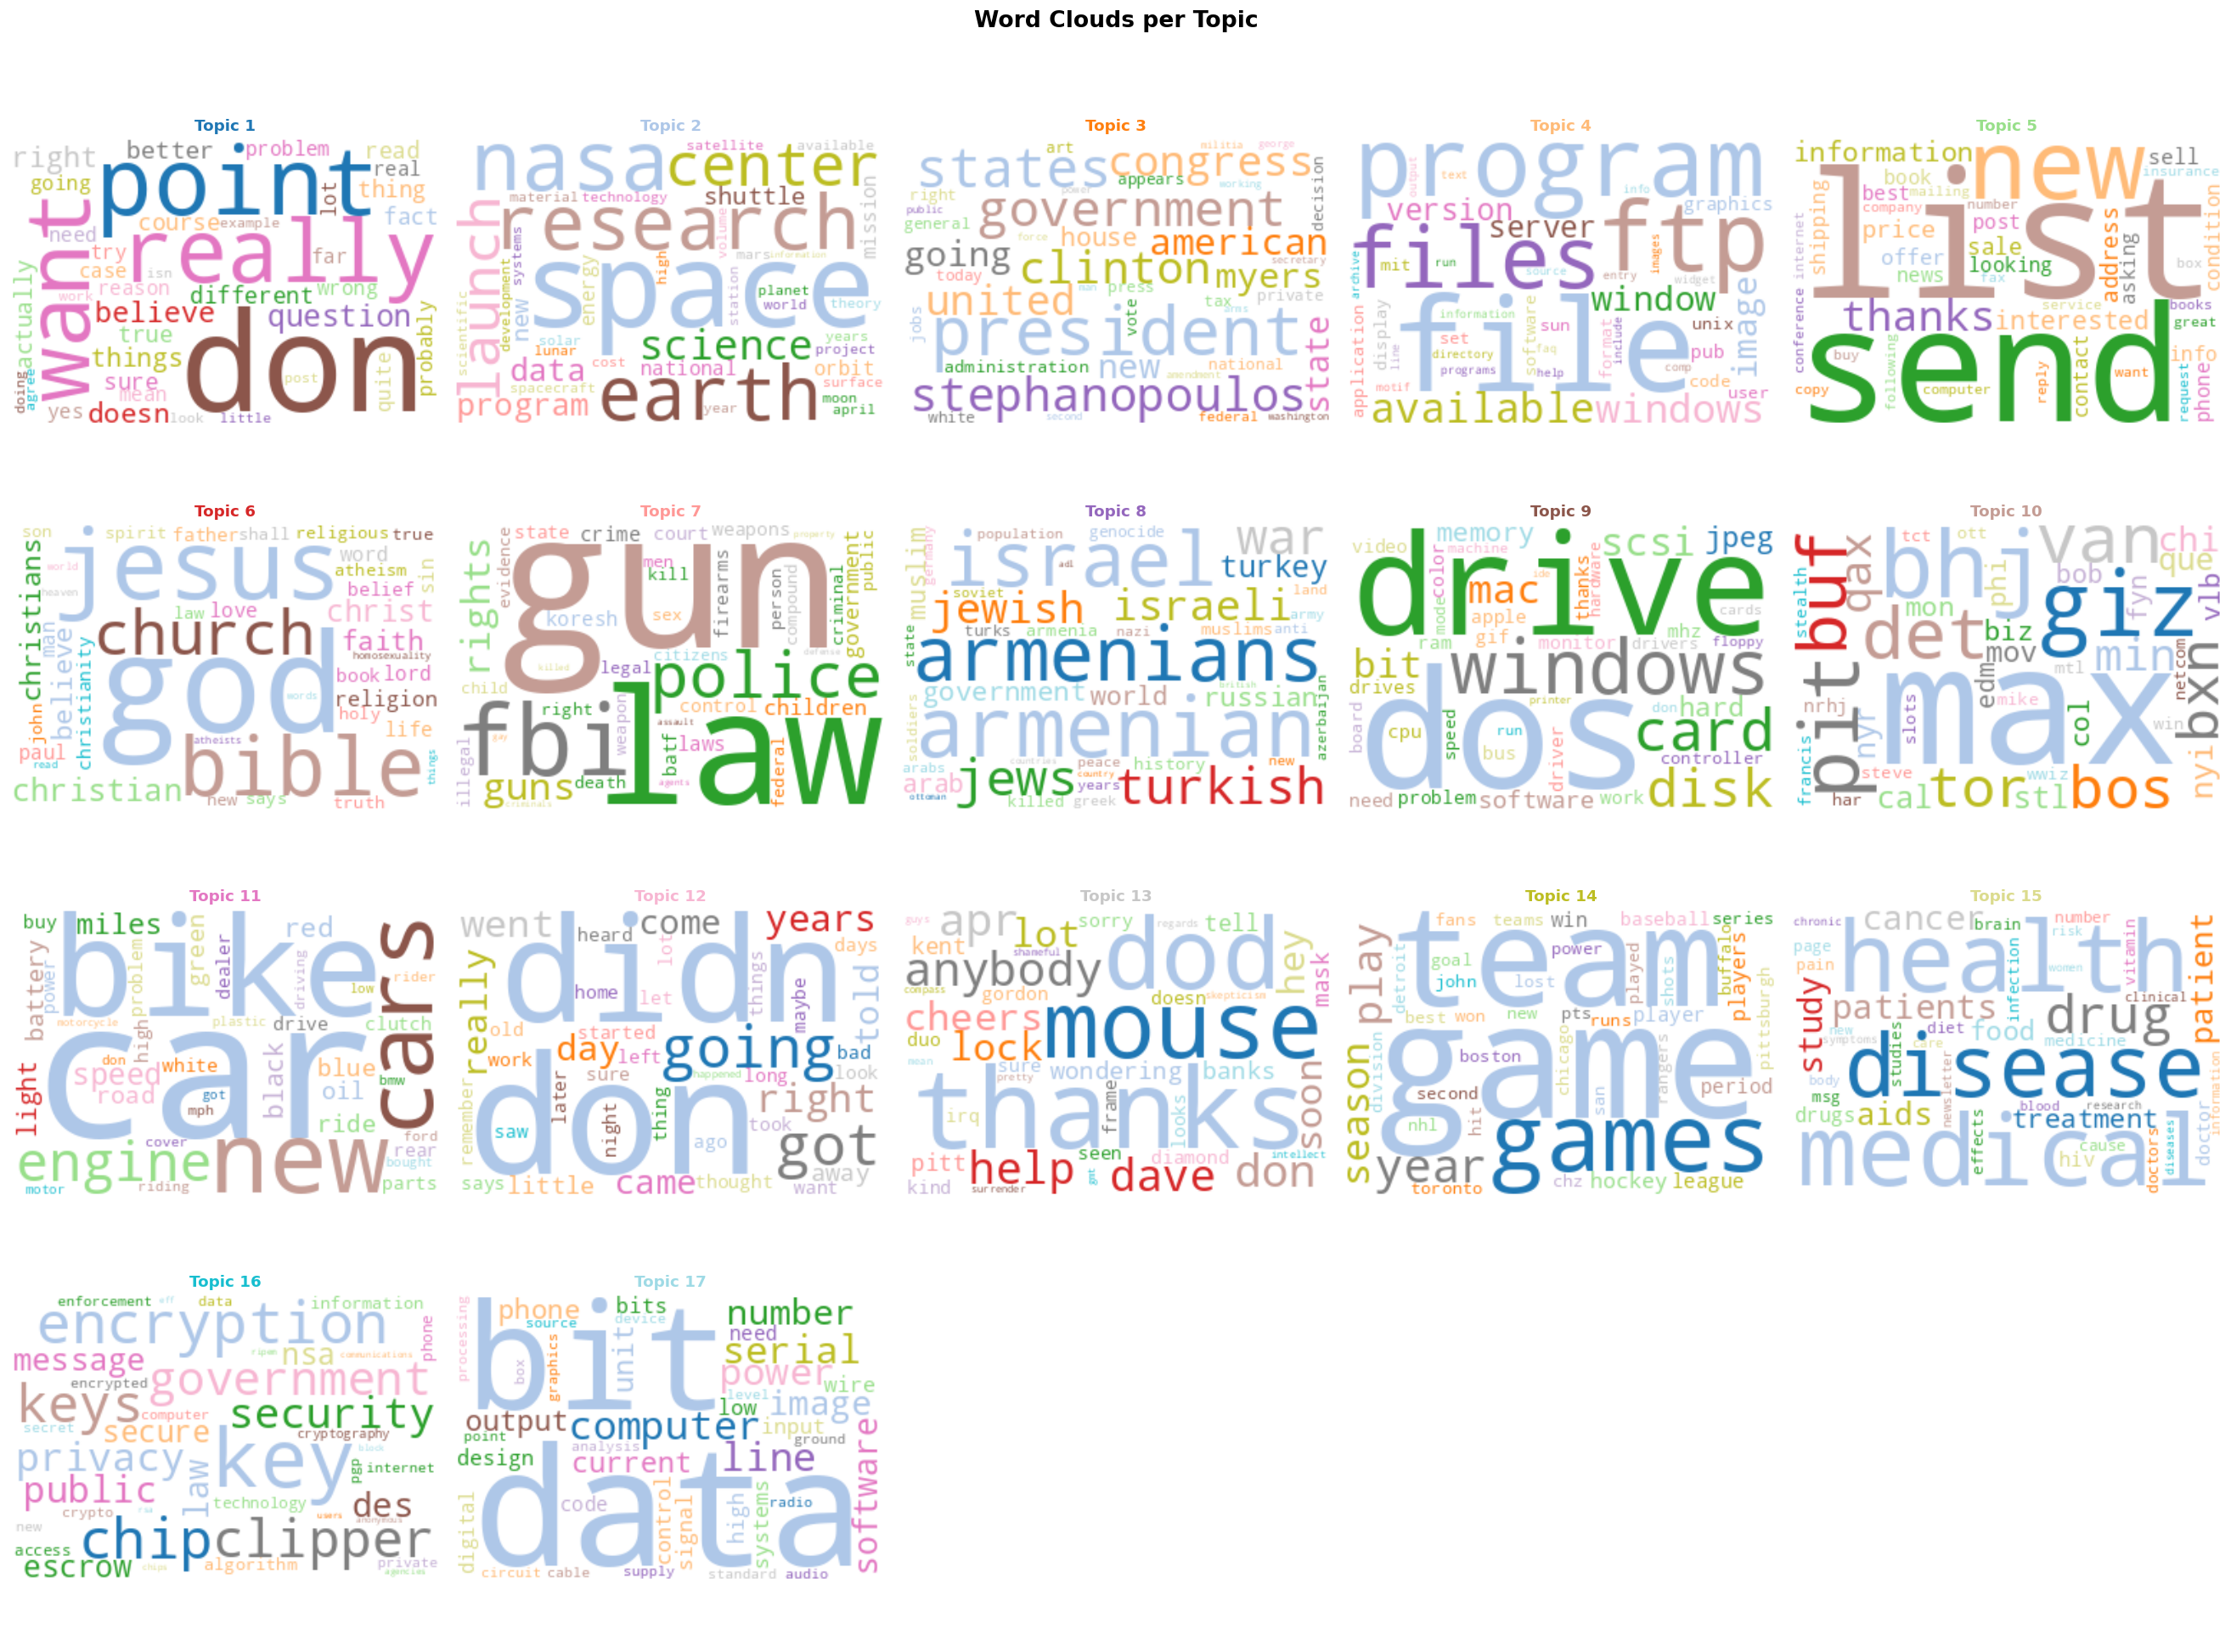

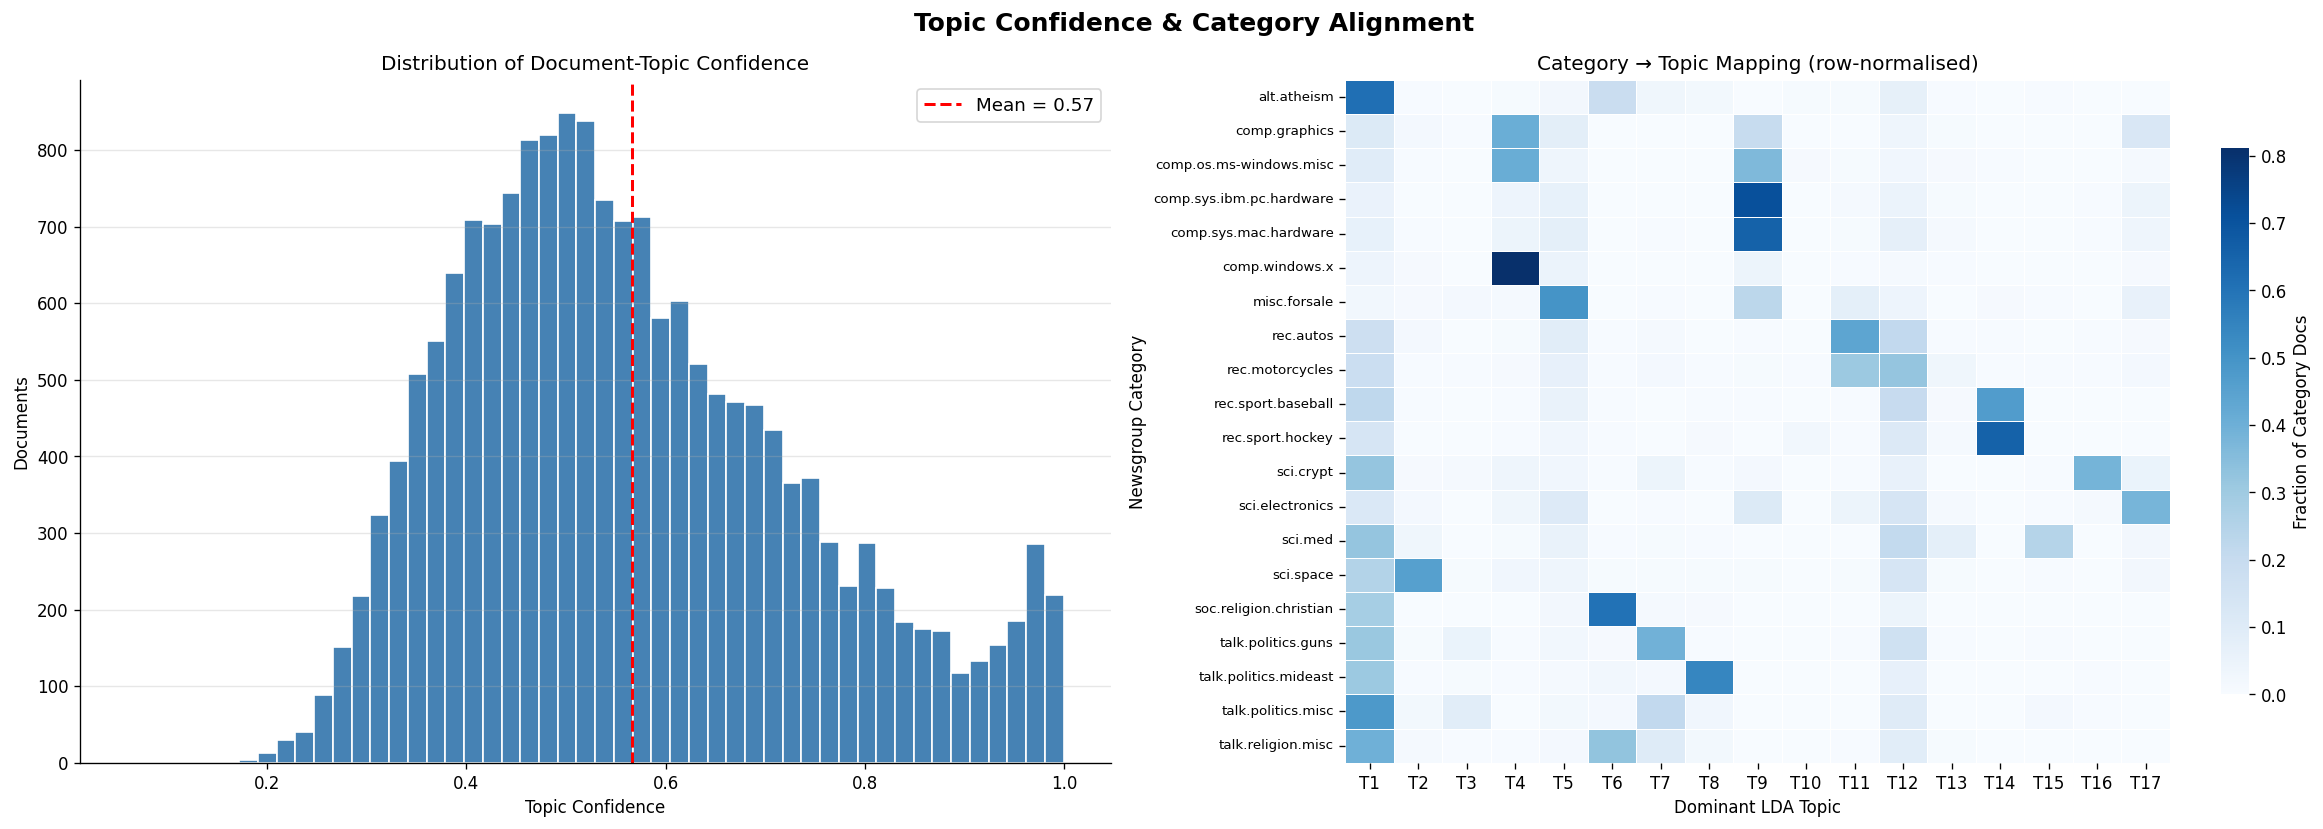

💾 Interactive viz saved → lda_interactive.html


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
0      59.192421  48.063408       1        1  18.988836
1      14.506983   7.372507       2        1   5.752820
2      11.576440  38.014297       3        1   3.272828
3     -41.770699  -4.370373       4        1  11.305895
4     -13.422344  19.967737       5        1   5.254897
5      38.766182  25.207823       6        1   7.128797
6      -9.691644 -10.809028       7        1   4.442767
7     -24.361116 -38.646229       8        1   5.890429
8      42.320072  -5.374500       9        1   7.553702
9     -41.367290  33.514442      10        1   1.383537
10     70.675804 -20.638470      11        1   3.223027
11     27.224371  65.518280      12        1   9.883143
12     43.696293 -42.691826      13        1   1.136745
13    -12.882160  58.609856      14        1   4.524150
14      8.407093 -53.449089      15        1   2.401468
15     70.857178  14.396618      16        1   2.985775
16     17.518169 -23.140461      17        1   4.871185, topic_info=        Term         Freq        Total Category  logprob  loglift
2734     max  4760.000000  4760.000000  Default  30.0000  30.0000
1915     god  3367.000000  3367.000000  Default  29.0000  29.0000
1363     don  6506.000000  6506.000000  Default  28.0000  28.0000
2433     key  1591.000000  1591.000000  Default  27.0000  27.0000
4525  thanks  1952.000000  1952.000000  Default  26.0000  26.0000
...      ...          ...          ...      ...      ...      ...
2064    high   261.043601  1419.484426  Topic17  -5.3431   1.3285
818     code   236.400280  1042.927616  Topic17  -5.4422   1.5376
518      box   218.551989   721.757514  Topic17  -5.5207   1.8272
2956    need   238.677710  2642.236687  Topic17  -5.4326   0.6176
3339   point   221.695375  2153.001599  Topic17  -5.5065   0.7485

[1050 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
21        1  0.042897   access
21        2  0.042897   access
21        4  0.235935   access
21        5  0.102477   access
21        7  0.027407   access
...     ...       ...      ...
4986     17  0.025550      yes
4993      5  0.994032  zealand
4997      4  0.950075      zip
4997      9  0.047504      zip
4997     10  0.003393      zip

[3053 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17])


FINAL SUMMARY
  Search method    : Bayesian GP + Expected Improvement
  Evaluations      : 30 on 4,000-doc stratified subsample
  Best n_topics    : 17
  Best alpha (α)   : 0.01617
  Best beta (β)    : 0.01962
  Best decay       : 0.7585
  Log-Likelihood   : -8,429,076.08  (was -8,413,293.49)
  Perplexity       : 1,845.12  (was 1,819.32)
  Coherence (C_v)  : 0.6363  (was 0.6332)  Δ=+0.0031
✅ Done!


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [14]:
import matplotlib.patches as mpatches

PALETTE          = plt.cm.tab20(np.linspace(0, 1, max(N_TOPICS, 2)))
df_search_chrono = pd.DataFrame(search_history).sort_values('call')
cohs             = df_search_chrono['coherence'].values
calls            = df_search_chrono['call'].values
best_so_far      = np.maximum.accumulate(cohs)


# ─────────────────────────────────────────────────────────────
# FIG 1 — Bayesian Search Diagnostics (2×2)
# ─────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(18, 12))
fig1.suptitle('Bayesian Optimisation — Search Diagnostics', fontsize=16, fontweight='bold')

# 1a Convergence
ax = axes1[0, 0]
ax.scatter(calls, cohs, c=cohs, cmap='viridis', s=65, zorder=3, alpha=0.85)
ax.plot(calls, best_so_far, 'r-', lw=2.2, label='Best so far')
ax.axhline(baseline_coh, color='gray', ls='--', lw=1.5, label=f'Baseline ({baseline_coh:.4f})')
ax.axhline(coherence_score, color='gold', ls=':', lw=2, label=f'Final ({coherence_score:.4f})')
ax.axvspan(0.5, N_INITIAL_PTS+0.5, alpha=0.06, color='blue', label='Random phase')
ax.axvspan(N_INITIAL_PTS+0.5, N_CALLS+0.5, alpha=0.06, color='green', label='Bayesian phase')
ax.set_xlabel('Evaluation #'); ax.set_ylabel('Coherence (C_v)')
ax.set_title('Convergence Curve', fontweight='bold')
ax.legend(fontsize=8, loc='lower right'); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# 1b n_components vs coherence
ax = axes1[0, 1]
sc = ax.scatter(df_search_chrono['n_components'], cohs,
                c=cohs, cmap='RdYlGn', s=70, alpha=0.85)
ax.axvline(best_params['n_components'], color='red', ls='--', lw=1.5,
           label=f"Best n={best_params['n_components']}")
plt.colorbar(sc, ax=ax, label='Coherence')
ax.set_xlabel('n_components (Topics)'); ax.set_ylabel('Coherence (C_v)')
ax.set_title('Topics vs Coherence', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# 1c alpha vs coherence
ax = axes1[1, 0]
sc2 = ax.scatter(df_search_chrono['doc_topic_prior'], cohs,
                 c=cohs, cmap='RdYlGn', s=70, alpha=0.85)
ax.axvline(best_params['doc_topic_prior'], color='red', ls='--', lw=1.5,
           label=f"Best α={best_params['doc_topic_prior']:.4f}")
ax.set_xscale('log')
plt.colorbar(sc2, ax=ax, label='Coherence')
ax.set_xlabel('doc_topic_prior α (log scale)'); ax.set_ylabel('Coherence (C_v)')
ax.set_title('Alpha (α) vs Coherence', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# 1d beta vs coherence
ax = axes1[1, 1]
sc3 = ax.scatter(df_search_chrono['topic_word_prior'], cohs,
                 c=cohs, cmap='RdYlGn', s=70, alpha=0.85)
ax.axvline(best_params['topic_word_prior'], color='red', ls='--', lw=1.5,
           label=f"Best β={best_params['topic_word_prior']:.4f}")
ax.set_xscale('log')
plt.colorbar(sc3, ax=ax, label='Coherence')
ax.set_xlabel('topic_word_prior β (log scale)'); ax.set_ylabel('Coherence (C_v)')
ax.set_title('Beta (β) vs Coherence', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_bayes_diagnostics.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# FIG 2 — Baseline vs Optimised Metrics
# ─────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
fig2.suptitle('Baseline vs Optimised — Metric Comparison', fontsize=15, fontweight='bold')

metric_pairs = [
    ('Log-Likelihood', baseline_ll,  log_likelihood,  '#2196F3', True),
    ('Perplexity',     baseline_pp,  perplexity,      '#FF5722', False),
    ('Coherence (Cv)', baseline_coh, coherence_score, '#4CAF50', True),
]
for ax, (label, bval, oval, color, higher_better) in zip(axes2, metric_pairs):
    bars = ax.bar(['Baseline', 'Optimised'], [bval, oval],
                  color=['#BBBBBB', color], edgecolor='white', width=0.5)
    for bar, val in zip(bars, [bval, oval]):
        fmt = f'{val:,.4f}' if abs(val) < 100 else f'{val:,.1f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * (0.92 if val < 0 else 1.02),
                fmt, ha='center', va='bottom' if val >= 0 else 'top', fontsize=11, fontweight='bold')
    delta = oval - bval
    pct   = (oval / bval - 1) * 100
    improved = (higher_better and delta > 0) or (not higher_better and delta < 0)
    icon = '✅' if improved else '⚠️'
    ax.set_title(f'{label}\n{icon}  Δ = {delta:+.4f}  ({pct:+.1f}%)', fontsize=11, fontweight='bold')
    ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    margin = abs(bval - oval) * 0.3 + abs(bval) * 0.05
    ax.set_ylim(min(bval, oval) - margin, max(bval, oval) + margin)

plt.tight_layout()
plt.savefig('fig2_comparison.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# FIG 3 — Parallel Coordinates
# ─────────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(16, 6))
params_to_plot = ['n_components','doc_topic_prior','topic_word_prior','learning_decay']
param_labels   = ['n_topics', 'alpha α', 'beta β', 'learning_decay']

df_norm = df_search_chrono[params_to_plot].copy()
for col in params_to_plot:
    lo, hi = df_norm[col].min(), df_norm[col].max()
    df_norm[col] = (df_norm[col] - lo) / (hi - lo + 1e-10)

norm_c = Normalize(vmin=cohs.min(), vmax=cohs.max())
cmap_c = plt.cm.RdYlGn

for idx, row in df_search_chrono.iterrows():
    vals  = [df_norm.loc[idx, p] for p in params_to_plot]
    color = cmap_c(norm_c(row['coherence']))
    ax3.plot(range(4), vals, color=color, alpha=0.55, lw=1.2)

best_idx  = df_search_chrono['coherence'].idxmax()
best_vals = [df_norm.loc[best_idx, p] for p in params_to_plot]
ax3.plot(range(4), best_vals, 'r-', lw=3, zorder=5, label='Best config')
ax3.scatter(range(4), best_vals, color='red', s=110, zorder=6)

sm = ScalarMappable(norm=norm_c, cmap=cmap_c); sm.set_array([])
plt.colorbar(sm, ax=ax3, label='Coherence (C_v)', shrink=0.8)
ax3.set_xticks(range(4)); ax3.set_xticklabels(param_labels, fontsize=12)
ax3.set_ylabel('Normalised value'); ax3.legend(fontsize=10)
ax3.set_title('Parallel Coordinates — All Evaluations (red = best config)',
              fontsize=13, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
ax3.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_parallel_coords.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# FIG 4 — Document Distribution + Metrics Scorecard
# ─────────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(18, 6))
fig4.suptitle('Optimised LDA — Document Overview', fontsize=15, fontweight='bold')

ax = axes4[0]
tc = df_raw['dominant_topic'].value_counts().sort_index()
bars = ax.bar(tc.index, tc.values, color=PALETTE[:len(tc)], edgecolor='white', lw=0.5)
ax.set_xlabel('Topic'); ax.set_ylabel('Documents')
ax.set_title('Document Distribution Across Topics')
ax.set_xticks(range(1, N_TOPICS+1))
ax.bar_label(bars, fontsize=7, padding=2, rotation=90)
ax.set_ylim(0, tc.max() * 1.25)
ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)

ax2 = axes4[1]; ax2.axis('off')
cards = [
    ('Log-Likelihood', f'{log_likelihood:,.1f}', 'Higher → Better fit', '#2196F3'),
    ('Perplexity',     f'{perplexity:,.1f}',     'Lower → Better fit',  '#FF5722'),
    ('Coherence (Cv)', f'{coherence_score:.4f}',
     f'Δ {coherence_score-baseline_coh:+.4f} vs baseline ({(coherence_score/baseline_coh-1)*100:+.1f}%)',
     '#4CAF50'),
]
for i, (lbl, val, note, col) in enumerate(cards):
    y = 0.75 - i * 0.28
    ax2.add_patch(mpatches.FancyBboxPatch((0.05, y-0.08), 0.90, 0.22,
                   boxstyle='round,pad=0.02', facecolor=col, alpha=0.12,
                   transform=ax2.transAxes))
    ax2.text(0.12, y+0.07, lbl,  transform=ax2.transAxes, fontsize=13, fontweight='bold', color=col)
    ax2.text(0.12, y-0.01, val,  transform=ax2.transAxes, fontsize=20, fontweight='bold', color='#333')
    ax2.text(0.12, y-0.06, note, transform=ax2.transAxes, fontsize=10, color='#666', style='italic')
ax2.set_title('Final Model Metrics', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig4_doc_overview.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# FIG 5 — Top-words Heatmap
# ─────────────────────────────────────────────────────────────
N_HEAT = 10
top_n  = {k: v[:N_HEAT] for k, v in topics_dict.items()}
all_hw = list(dict.fromkeys(w for ws in top_n.values() for w in ws))
hw_idx = {w: i for i, w in enumerate(all_hw)}
hata   = np.zeros((N_TOPICS, len(all_hw)))
fn_list = list(feat_full)
for t_idx, words in enumerate(top_n.values()):
    norm_d = lda.components_[t_idx] / lda.components_[t_idx].sum()
    for w in words:
        if w in hw_idx and w in fn_list:
            hata[t_idx, hw_idx[w]] = norm_d[fn_list.index(w)]

fig5, ax5 = plt.subplots(figsize=(max(20, len(all_hw)*0.55), 9))
sns.heatmap(hata, ax=ax5,
            xticklabels=all_hw, yticklabels=[f'Topic {i+1}' for i in range(N_TOPICS)],
            cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Normalised Word Weight', 'shrink': 0.6})
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax5.set_yticklabels(ax5.get_yticklabels(), rotation=0, fontsize=9)
ax5.set_title(f'Top-{N_HEAT} Word Weights Heatmap (Optimised Model)',
              fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig5_heatmap.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# FIG 6 — Word Clouds
# ─────────────────────────────────────────────────────────────
ncols  = 5
nrows  = int(np.ceil(N_TOPICS / ncols))
fig6, axes6 = plt.subplots(nrows, ncols, figsize=(22, nrows*4))
fig6.suptitle('Word Clouds per Topic', fontsize=16, fontweight='bold', y=1.01)
flat = axes6.flatten()

for t_idx in range(N_TOPICS):
    wfreq = {feat_full[i]: lda.components_[t_idx][i] for i in range(len(feat_full))}
    wc = WordCloud(width=300, height=200, background_color='white',
                   max_words=40, colormap='tab20',
                   random_state=RANDOM_STATE).generate_from_frequencies(wfreq)
    flat[t_idx].imshow(wc, interpolation='bilinear')
    flat[t_idx].set_title(f'Topic {t_idx+1}', fontsize=11, fontweight='bold',
                          color=mcolors.to_hex(PALETTE[t_idx % len(PALETTE)]))
    flat[t_idx].axis('off')

for j in range(N_TOPICS, len(flat)):
    flat[j].axis('off')

plt.tight_layout()
plt.savefig('fig6_wordclouds.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# FIG 7 — Confidence Distribution + Category-Topic Heatmap
# ─────────────────────────────────────────────────────────────
fig7, axes7 = plt.subplots(1, 2, figsize=(20, 7))
fig7.suptitle('Topic Confidence & Category Alignment', fontsize=15, fontweight='bold')

ax7a = axes7[0]
ax7a.hist(df_raw['topic_confidence'], bins=50, color='steelblue', edgecolor='white', lw=0.4)
ax7a.axvline(df_raw['topic_confidence'].mean(), color='red', ls='--', lw=1.8,
             label=f"Mean = {df_raw['topic_confidence'].mean():.2f}")
ax7a.set_xlabel('Topic Confidence'); ax7a.set_ylabel('Documents')
ax7a.set_title('Distribution of Document-Topic Confidence')
ax7a.legend(fontsize=11); ax7a.grid(axis='y', alpha=0.3)
ax7a.spines[['top','right']].set_visible(False)

ax7b = axes7[1]
ct = pd.crosstab(df_raw['category'], df_raw['dominant_topic'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)
sns.heatmap(ct_norm, ax=ax7b, cmap='Blues', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Fraction of Category Docs', 'shrink': 0.8},
            xticklabels=[f'T{i}' for i in range(1, N_TOPICS+1)])
ax7b.set_xlabel('Dominant LDA Topic'); ax7b.set_ylabel('Newsgroup Category')
ax7b.set_title('Category → Topic Mapping (row-normalised)')
ax7b.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('fig7_confidence_category.png', bbox_inches='tight')
plt.show()


# ─────────────────────────────────────────────────────────────
# FIG 8 — pyLDAvis interactive
# ─────────────────────────────────────────────────────────────
try:
    import pyLDAvis, pyLDAvis.lda_model as pyldavis_lda
    pyLDAvis.enable_notebook()
    vis = pyldavis_lda.prepare(lda, dtm_full, vec_full, mds='tsne', sort_topics=False)
    pyLDAvis.save_html(vis, 'lda_interactive.html')
    print('💾 Interactive viz saved → lda_interactive.html')
    display(vis)
except Exception as e:
    print(f'pyLDAvis skipped: {e}')


# ─────────────────────────────────────────────────────────────
# FINAL SUMMARY
# ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)
print(f'  Search method    : Bayesian GP + Expected Improvement')
print(f'  Evaluations      : {N_CALLS} on {len(df_sub):,}-doc stratified subsample')
print(f'  Best n_topics    : {best_params["n_components"]}')
print(f'  Best alpha (α)   : {best_params["doc_topic_prior"]:.5f}')
print(f'  Best beta (β)    : {best_params["topic_word_prior"]:.5f}')
print(f'  Best decay       : {best_params["learning_decay"]:.4f}')
print(f'  Log-Likelihood   : {log_likelihood:,.2f}  (was {baseline_ll:,.2f})')
print(f'  Perplexity       : {perplexity:,.2f}  (was {baseline_pp:,.2f})')
print(f'  Coherence (C_v)  : {coherence_score:.4f}  (was {baseline_coh:.4f})  '
      f'Δ={coherence_score-baseline_coh:+.4f}')
print('='*60)
print('✅ Done!')